# Import libraries

In [1]:
import sys
import numpy as np

import matplotlib as mpl

mpl.use('Agg')

import matplotlib.pyplot as plt
import postcactus as pc
from postcactus.simdir import SimDir
from postcactus import visualize as viz
from postcactus import grid_data as gd
from postcactus.fourier_util import *

from postcactus import cactus_grid_h5 as cgr
from postcactus import cactus_grid_ascii as cgra

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

import matplotlib.colors as colors

/mnt/rafast/chabanov/anaconda3/lib/python3.9/site-packages/scipy/ndimage/interpolation.py:603: UserWarning: The behavior of affine_transform with a 1-D array supplied for the matrix parameter has changed in SciPy 0.18.0.
  warnings.warn(


In [2]:
#%matplotlib widget
#%matplotlib notebook
%matplotlib inline

# Load simulation directories

In [3]:
sd_dict = {"tnt" : SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/rates_dU_10_15_tnt_HR/"),
           "low" : SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_linear_HR/"),
           "med" : SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_pwl_0.5_HR/"),
           "high" : SimDir("/mnt/raarchive/chabanov/direct_Urca_runs/dU_10_15_pwl_0.75_HR/")}

In [4]:
key_list = ["tnt","low","med","high"]

In [5]:
t_merge_dict_true = {'low': 4254.444444444444, 
                     'high': 4255.555555555556,
                     'tnt': 4252.222222222223,
                     'med': 4254.444444444444}

# Defintions for plotting and constants

In [6]:
factor = 1.61887093132742e-18
rhosat = 2.7e14 * factor

linthresh = 1.e-15
linscale = 1.

vmin = 5.
vmax = 5.e-1

#cont = [1.e13*factor,1.e14*factor,5.e14*factor,7.e14*factor]
cont = [0.05,0.2]

#cont_label = {1.e13*factor:"$\\mathbf{ 10^{13} \\ \\mathrm{\mathbf{g}} \\ \\mathrm{\\mathbf{cm}}^{-3} }$",
#              7.e14*factor:"$\\mathbf{ 7 \\times 10^{14} }$"}
#cont_label = {1.e13*factor:"$\\mathbf{ 10^{13} }$",
#              7.e14*factor:"$\\mathbf{ 7 \\times 10^{14} }$"}
#cont_label = {1.e13*factor:"$\\mathbf{ 10^{13} \\ \\mathrm{\mathbf{g}} \\ \\mathrm{\\mathbf{cm}}^{-3} }$",
#              7.e14*factor:"$\\mathbf{ 7 \\times 10^{14} \\ \\mathrm{\\mathbf{g}} \\ \\mathrm{\\mathbf{cm}}^{-3} }$"}

millis = 203.01930744592713
msun_to_km = 1.4766696910334391 

color_stream = "red"

plotting_styles = ["r-","g-","b-","k-","yo-","rx-","gx-","bx-","kx-","yx-","r--","g--","b--","k--","y--"]

# Note that I am using the neutron mass here
# That shouldn't be a problem
kB_over_mb = 8.617332478e-5 / 939.565e6
convert_temp = pow(kB_over_mb,-1.)*8.617332478e-11

direct_dict = {'low':  2.4024024024024024*0.0004029425588922455, 
              'high': 1.5529899348727056*0.0004029425588922455,
              'tnt':  8.206669603088548*0.0004029425588922455,
              'med':  1.857667584940312*0.0004029425588922455}

# ------------------------------------------------------------

# A) Load scalar data

# A.1) Variable names

In [7]:
list_of_max_vars = ["rho_b","pi","temp"]
list_of_min_vars = ["alp"]

# A.2) Load data

In [8]:
data_dict = {}

for key in sd_dict:
    
    tmp_dict = {}
    
    for i in range(0,len(list_of_max_vars)):
        
        time_s = sd_dict[key].ts.max[list_of_max_vars[i]]
        
        dummy_dict = {list_of_max_vars[i]+"_max" : time_s}
        
        tmp_dict.update(dummy_dict)
        
    for i in range(0,len(list_of_min_vars)):
        
        time_s = sd_dict[key].ts.min[list_of_min_vars[i]]
        
        dummy_dict = {list_of_min_vars[i]+"_min" : time_s}
        
        tmp_dict.update(dummy_dict)
    
    data_dict.update({key:tmp_dict})

# A.3) Plot

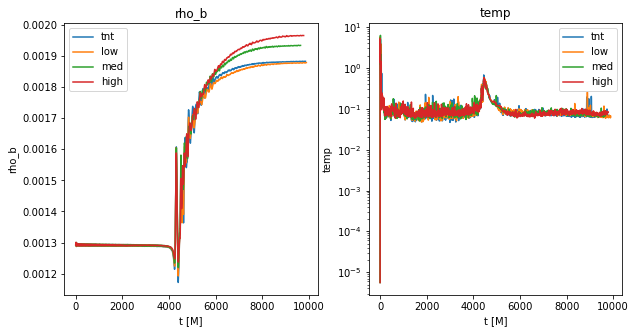

In [9]:
key1 = "rho_b"

mm1 = "_max"

key2 = "temp"

mm2 = "_max"

fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(10,5))

for key in sd_dict:
    ax[0].plot(data_dict[key][key1+mm1].t,data_dict[key][key1+mm1].y,label=key)
    
#ax.set_xlim(4.0,8.0)
#ax.set_yscale('log')
#ax.set_ylim(1e-15,1e-3)
ax[0].set_ylabel(key1)
ax[0].set_xlabel("t [M]")

ax[0].set_title(key1)
ax[0].legend()

for key in sd_dict:
    ax[1].plot(data_dict[key][key2+mm2].t,data_dict[key][key2+mm2].y,label=key)
    
#ax.set_xlim(4.0,8.0)
ax[1].set_yscale('log')
#ax.set_ylim(1e-15,1e-3)
ax[1].set_ylabel(key2)
ax[1].set_xlabel("t [M]")

ax[1].set_title(key2)
ax[1].legend()

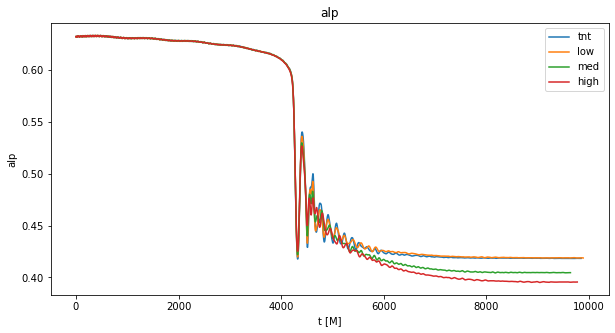

In [10]:
key1 = "alp"

mm1 = "_min"

fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(10,5))

for key in sd_dict:
    ax.plot(data_dict[key][key1+mm1].t,data_dict[key][key1+mm1].y,label=key)
    
#ax.set_xlim(4.0,8.0)
#ax.set_yscale('log')
#ax.set_ylim(1e-15,1e-3)
ax.set_ylabel(key1)
ax.set_xlabel("t [M]")

ax.set_title(key1)
ax.legend()

# ------------------------------------------------------------

# Grid settings

In [11]:
cells_x1 = 800
cells_x2 = 800

box_bound = 50.

mini_x1 = -box_bound
mini_x2 = -box_bound

maxi_x1 = box_bound
maxi_x2 = box_bound

#mini_x1 = -box_bound/2.
#mini_x2 = -box_bound/2.

#maxi_x1 = box_bound/2.
#maxi_x2 = box_bound/2.

###

min_x1 = -box_bound
min_x2 = -box_bound

max_x1 = box_bound
max_x2 = box_bound

g = gd.RegGeom([cells_x1,cells_x2], [min_x1,min_x2], x1=[max_x1,max_x2])

# Read pickle files

In [12]:
import pickle

path_dict = {"tnt":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "rates_dU_10_15_tnt_HR/pi--rates_dU_10_15_tnt_HR.pickle",
            "low":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_linear_HR/pi--dU_10_15_linear_HR.pickle",
            "med":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_pwl_0.5_HR/pi--dU_10_15_pwl_0.5_HR.pickle",
            "high":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_pwl_0.75_HR/pi--dU_10_15_pwl_0.75_HR.pickle"}

path_dict_2 = {"tnt":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "rates_dU_10_15_tnt_HR/P--rates_dU_10_15_tnt_HR.pickle",
            "low":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_linear_HR/P--dU_10_15_linear_HR.pickle",
            "med":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_pwl_0.5_HR/P--dU_10_15_pwl_0.5_HR.pickle",
            "high":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_pwl_0.75_HR/P--dU_10_15_pwl_0.75_HR.pickle"}

path_dict_3 = {"tnt":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "rates_dU_10_15_tnt_HR/temp--rates_dU_10_15_tnt_HR.pickle",
            "low":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_linear_HR/temp--dU_10_15_linear_HR.pickle",
            "med":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_pwl_0.5_HR/temp--dU_10_15_pwl_0.5_HR.pickle",
            "high":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_pwl_0.75_HR/temp--dU_10_15_pwl_0.75_HR.pickle"}

path_dict_rho = {"tnt":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "rates_dU_10_15_tnt_HR/rho_b--rates_dU_10_15_tnt_HR.pickle",
            "low":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_linear_HR/rho_b--dU_10_15_linear_HR.pickle",
            "med":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_pwl_0.5_HR/rho_b--dU_10_15_pwl_0.5_HR.pickle",
            "high":"/mnt/rafast/chabanov/viscous_merger_dUHR_tntyst_analysis/2d-data/"+
                   "dU_10_15_pwl_0.75_HR/rho_b--dU_10_15_pwl_0.75_HR.pickle"}

pickle_dict = {}

for key in path_dict:
    
    with open(path_dict[key], 'rb') as r:
        # The protocol version used is detected automatically, so we do not
        # have to specify it.
        data_dict = pickle.load(r)
        pickle_dict.update({key:data_dict})
        
pickle_dict_2 = {}
        
for key in path_dict_2:
    
    with open(path_dict_2[key], 'rb') as f:
        # The protocol version used is detected automatically, so we do not
        # have to specify it.
        data_dict_2 = pickle.load(f)
        pickle_dict_2.update({key:data_dict_2})
        
pickle_dict_3 = {}
        
for key in path_dict_3:
    
    with open(path_dict_3[key], 'rb') as f:
        # The protocol version used is detected automatically, so we do not
        # have to specify it.
        data_dict_3 = pickle.load(f)
        pickle_dict_3.update({key:data_dict_3})
        
pickle_dict_rho = {}

for key in path_dict_rho:
    
    with open(path_dict_rho[key], 'rb') as g:
        # The protocol version used is detected automatically, so we do not
        # have to specify it.
        data_dict_rho = pickle.load(g)
        pickle_dict_rho.update({key:data_dict_rho})

In [13]:
for elem in pickle_dict['tnt']:
    print(elem)

0
128
256
384
512
640
768
896
1024
1152
1280
1408
1536
1664
1792
1920
2048
2176
2304
2432
2560
2688
2816
2944
3072
3200
3328
3456
3584
3712
3840
3968
4096
4224
4352
4480
4608
4736
4864
4992
5120
5248
5376
5504
5632
5760
5888
6016
6144
6272
6400
6528
6656
6784
6912
7040
7168
7296
7424
7552
7680
7808
7936
8064
8192
8320
8448
8576
8704
8832
8960
9088
9216
9344
9472
9600
9728
9856
9984
10112
10240
10368
10496
10624
10752
10880
11008
11136
11264
11392
11520
11648
11776
11904
12032
12160
12288
12416
12544
12672
12800
12928
13056
13184
13312
13440
13568
13696
13824
13952
14080
14208
14336
14464
14592
14720
14848
14976
15104
15232
15360
15488
15616
15744
15872
16000
16128
16256
16384
16512
16640
16768
16896
17024
17152
17280
17408
17536
17664
17792
17920
18048
18176
18304
18432
18560
18688
18816
18944
19072
19200
19328
19456
19584
19712
19840
19968
20096
20224
20352
20480
20608
20736
20864
20992
21120
21248
21376
21504
21632
21760
21888
22016
22144
22272
22400
22528
22656
22784
22912
23040
231

In [14]:
print(pickle_dict['tnt'][str(197376)])

Shape      = [800 800]
Num ghosts  = [0 0]
Ref. level  = -1
Component   = -1
Edge0       = [-50. -50.]
  /delta    = [-399.5 -399.5]
Edge1       = [50. 50.]
  /delta    = [399.5 399.5]
Volume      = 10025.046953247254
Delta       = [0.12515645 0.12515645]
Time        = 6853.333333333334
Iteration   = 197376



In [15]:
print(pickle_dict['tnt'][str(197376)].time)

6853.333333333334


# Plots

In [112]:
my_vmax=1
my_vmin=1e-4
#RdBu_r
#RdGy_r
#Greys
cm1     = viz.get_color_map("PRGn")

string_dens1 = "black"
string_dens2 = "white"

clrs1   = [string_dens1,string_dens1,string_dens1]
clrs2   = [string_dens2,string_dens2,string_dens2]

dens_stream0 = 2.0

lw_0 = 3

rho_levels = [(1.-0.9975)*0.00073157182561,0.00073157182561,0.0014]

styler = ["dashed","solid","dotted"]

font_size = 25

for elem in rho_levels:
    print(elem/factor/1e15)

0.001129756257050894
0.45190250282036726
0.8648002585678939


In [102]:
for elem in pickle_dict:
    print(pickle_dict[elem][str(197376)].time)

6853.333333333334
6853.333333333334
6853.333333333334
6853.333333333334


In [103]:
all_it = {}
for key in pickle_dict:
    all_it.update({key:[]})

for key in pickle_dict:
    for elem in pickle_dict[key]:
        all_it[key].append(int(elem))

for key in all_it:
    all_it[key].sort()

all_times = {}

for key in pickle_dict:
    all_times.update({key:[]})
    for i in range(0,len(all_it[key])):
        all_times[key].append(pickle_dict[key][str(all_it[key][i])].time)
        
def find_it(time):
    out = {}
    for key in all_times:
        my_time = time*millis+t_merge_dict_true[key]
        for i in range(0,len(all_times[key])):
            if(all_times[key][i]>=my_time):
                out.update({key:(str(all_it[key][i]),i)})
                break
    return out  

In [104]:
for key in all_it:
    print(len(all_it[key]))
    
MINLEN = 2170

2217
2226
2170
2200


{'tnt': ('131584', 1028), 'low': ('131712', 1029), 'med': ('131712', 1029), 'high': ('131712', 1029)}


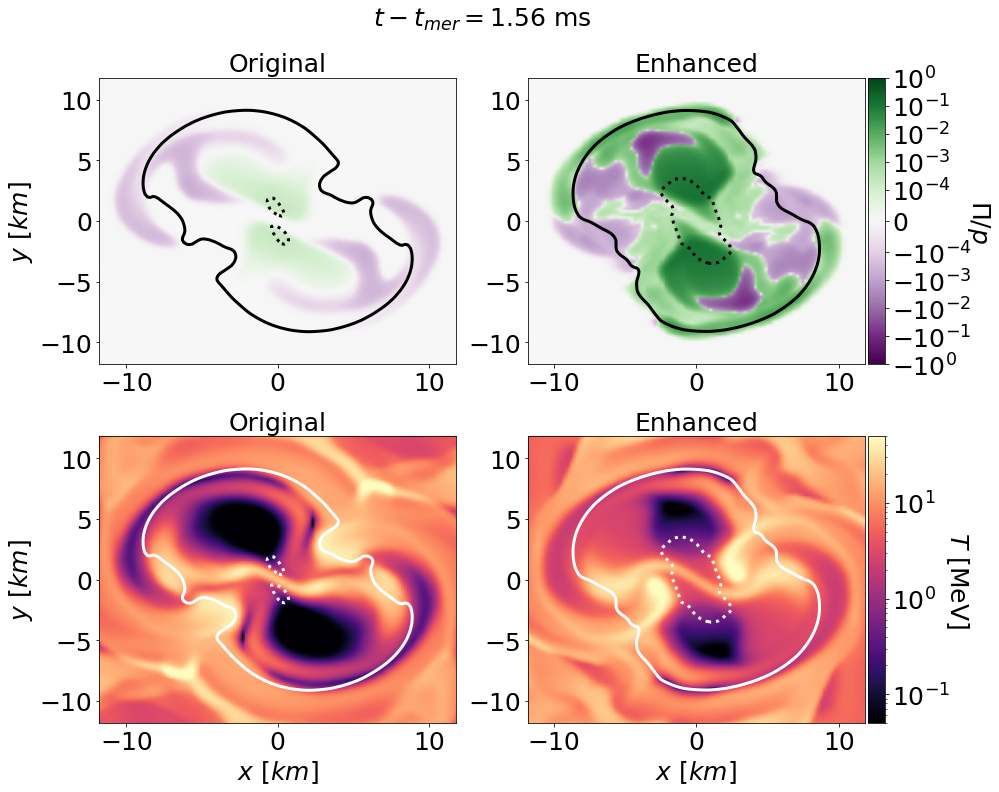

In [110]:
time = 1.55
this_it = find_it(time)
print(this_it)

fig,ax = plt.subplots(2,2,figsize=(14,11))

left  = 0.12     # the left side of the subplots of the figure
right = 0.9    # the right side of the subplots of the figure
bottom = 0.085   # the bottom of the subplots of the figure
top = 0.9      # the top of the subplots of the figure
wspace = 0.2    # the amount of width reserved for blank space between subplots
hspace = 0.25    # the amount of height reserved for white space between subplots

plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

for elem in ax:
    for elem2 in elem:
        elem2.set_ylim(-8.*msun_to_km,8.*msun_to_km)
        elem2.set_xlim(-8.*msun_to_km,8.*msun_to_km)
    
key = 'tnt'
    
plot0 = ax[0,0].pcolormesh(np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                      np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                      np.transpose(pickle_dict[key][this_it[key][0]].data/
                                   pickle_dict_2[key][this_it[key][0]].data),
                   #norm=colors.SymLogNorm(vmin=-1e-2,vmax=1e-2,linthresh=1e-6,linscale=1.),
                   norm=colors.SymLogNorm(vmin=-my_vmax,vmax=my_vmax,linthresh=my_vmin,linscale=1.),
                   cmap=cm1, shading='gouraud',rasterized=True)

ax[0,0].contour(np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                    np.transpose(pickle_dict_rho[key][this_it[key][0]].data),
                       rho_levels, colors=clrs1,
                       linewidths=lw_0,linestyles=styler);

#ax[0,0].contour(np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
#                np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[1])*msun_to_km,
#                    np.transpose(pickle_dict_rho[key][this_it[key][0]].data),
#                       [direct_dict[key]], colors="fuchsia",
#                       linewidths=lw_0,linestyles="solid");

ax[0,0].set_title("Original",
                  fontsize=font_size)

key = 'high'
    
plot1 = ax[0,1].pcolormesh(np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                      np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                      np.transpose(pickle_dict[key][this_it[key][0]].data/
                                   pickle_dict_2[key][this_it[key][0]].data),
                   norm=colors.SymLogNorm(vmin=-my_vmax,vmax=my_vmax,linthresh=my_vmin,linscale=1.),
                   cmap=cm1, shading='gouraud',rasterized=True)

ax[0,1].contour(np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                    np.transpose(pickle_dict_rho[key][this_it[key][0]].data),
                       rho_levels, colors=clrs1,
                       linewidths=lw_0,linestyles=styler);

#ax[0,1].contour(np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
#                np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[1])*msun_to_km,
#                    np.transpose(pickle_dict_rho[key][this_it[key][0]].data),
#                       [direct_dict[key]], colors="fuchsia",
#                       linewidths=lw_0,linestyles="solid");

ax[0,1].set_title("Enhanced",
                  fontsize=font_size)

key = 'tnt'
    
plot2 = ax[1,0].pcolormesh(np.transpose(pickle_dict_3[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                      np.transpose(pickle_dict_3[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                      np.transpose(pickle_dict_3[key][this_it[key][0]].data*convert_temp),
                   norm=colors.LogNorm(vmin=5e-2,vmax=50),
                   cmap="magma", shading='gouraud',rasterized=True)

ax[1,0].contour(np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                    np.transpose(pickle_dict_rho[key][this_it[key][0]].data),
                       rho_levels, colors=clrs2,
                       linewidths=lw_0,linestyles=styler);

#ax[1,0].contour(np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
#                np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[1])*msun_to_km,
#                    np.transpose(pickle_dict_rho[key][this_it[key][0]].data),
#                       [direct_dict[key]], colors="fuchsia",
#                       linewidths=lw_0,linestyles="solid");
                  
ax[1,0].set_title("Original",
                  fontsize=font_size)

key = 'high'
    
plot3 = ax[1,1].pcolormesh(np.transpose(pickle_dict_3[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                      np.transpose(pickle_dict_3[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                      np.transpose(pickle_dict_3[key][this_it[key][0]].data*convert_temp),
                   norm=colors.LogNorm(vmin=5e-2,vmax=50),
                   cmap="magma", shading='gouraud',rasterized=True)

ax[1,1].contour(np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                    np.transpose(pickle_dict_rho[key][this_it[key][0]].data),
                       rho_levels, colors=clrs2,
                       linewidths=lw_0,linestyles=styler);

#ax[1,1].contour(np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
#                np.transpose(pickle_dict_rho[key][this_it[key][0]].coords2d()[1])*msun_to_km,
#                    np.transpose(pickle_dict_rho[key][this_it[key][0]].data),
#                       [direct_dict[key]], colors="fuchsia",
#                       linewidths=lw_0,linestyles="solid");
                  
ax[1,1].set_title("Enhanced",
                  fontsize=font_size)


ax[1,0].set_xlabel("$x~[km]$",fontsize=font_size)
ax[1,1].set_xlabel("$x~[km]$",fontsize=font_size)
ax[0,0].set_ylabel("$y~[km]$",fontsize=font_size)
ax[1,0].set_ylabel("$y~[km]$",fontsize=font_size)

for elem in ax:
    for elem2 in elem:
        elem2.xaxis.set_tick_params(labelsize=font_size)
        elem2.yaxis.set_tick_params(labelsize=font_size)
        
divider0 = make_axes_locatable(ax[0,0])
divider1 = make_axes_locatable(ax[0,1])
divider2 = make_axes_locatable(ax[1,0])
divider3 = make_axes_locatable(ax[1,1])

#caxx0 = divider0.append_axes("right", size="5%", pad=0.05)
#cbar0 = plt.colorbar(plot0,cax=caxx0)
#cbar0.ax.set_ylabel('$\\Pi/p$',rotation=90+180,labelpad=20,fontsize=font_size)
#cbar0.ax.tick_params(labelsize=font_size)

caxx1 = divider1.append_axes("right", size="5%", pad=0.05)
cbar1 = plt.colorbar(plot1,cax=caxx1)
cbar1.ax.set_ylabel('$\\Pi/p$',rotation=90+180,labelpad=20,fontsize=font_size)
cbar1.ax.tick_params(labelsize=font_size)

#caxx2 = divider2.append_axes("right", size="5%", pad=0.05)
#cbar2 = plt.colorbar(plot2,cax=caxx2)
#cbar2.ax.set_ylabel('$T~[\\mathrm{MeV}]$',rotation=90+180,labelpad=20,fontsize=font_size)
#cbar2.ax.tick_params(labelsize=font_size)

caxx3 = divider3.append_axes("right", size="5%", pad=0.05)
cbar3 = plt.colorbar(plot3,cax=caxx3)
cbar3.ax.set_ylabel('$T~[\\mathrm{MeV}]$',rotation=90+180,labelpad=20,fontsize=font_size)
cbar3.ax.tick_params(labelsize=font_size)

plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

fig.suptitle("$t-t_{mer} = "+str(round(
    (all_times[key][this_it["tnt"][1]]-t_merge_dict_true["tnt"])/millis,3))+
             "~\\mathrm{ms}$",
             fontsize=font_size,y=0.99)

#plt.show()
plt.savefig("./pip_temp.pdf",bbox_inches="tight",dpi=500)

In [53]:
plt.close('all')

# Movie

In [ ]:
# Not updated with settings above

In [ ]:
plt.style.use('default')

In [ ]:
time = -5
this_it = find_it(time)
print(this_it)

In [ ]:
COUNT = int(0)

In [ ]:
for iii in range(700,MINLEN,3):
    
    print(iii)

    this_it = {}
    
    for key in all_it:
        this_it.update({key:(str(all_it[key][iii]),-1)})

    fig,ax = plt.subplots(2,2,figsize=(14,11))

    left  = 0.12     # the left side of the subplots of the figure
    right = 0.95    # the right side of the subplots of the figure
    bottom = 0.085   # the bottom of the subplots of the figure
    top = 0.95      # the top of the subplots of the figure
    wspace = 0.25    # the amount of width reserved for blank space between subplots
    hspace = 0.2    # the amount of height reserved for white space between subplots

    plt.subplots_adjust(left=left, bottom=bottom, right=right, top=top, wspace=wspace, hspace=hspace)

    for elem in ax:
        for elem2 in elem:
            elem2.set_ylim(-23.*msun_to_km,23.*msun_to_km)
            elem2.set_xlim(-23.*msun_to_km,23.*msun_to_km)
    
    key = 'tnt'
    
    plot0 = ax[0,0].pcolormesh(np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                      np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                      np.transpose(pickle_dict[key][this_it[key][0]].data),
                   norm=colors.LogNorm(vmin=my_vmin,vmax=my_vmax),
                   cmap=cm1, shading='nearest',rasterized=True)

    ax[0,0].contour(np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                    np.transpose(pickle_dict[key][this_it[key][0]].data),
                       rho_levels, colors=clrs,
                       linewidths=lw_0,linestyles=styler);

    ax[0,0].set_title(key+"$;~t-t_{mer} = $"+str(round(
        (all_times[key][iii]-t_merge_dict_true[key])/millis,3)),
                  fontsize=font_size)

    key = 'low'
    
    plot1 = ax[0,1].pcolormesh(np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                      np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                      np.transpose(pickle_dict[key][this_it[key][0]].data),
                   norm=colors.LogNorm(vmin=my_vmin,vmax=my_vmax),
                   cmap=cm1, shading='nearest',rasterized=True)

    ax[0,1].contour(np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                    np.transpose(pickle_dict[key][this_it[key][0]].data),
                       rho_levels, colors=clrs,
                       linewidths=lw_0,linestyles=styler);

    ax[0,1].set_title(key+"$;~t-t_{mer} = $"+str(round(
        (all_times[key][iii]-t_merge_dict_true[key])/millis,3)),
                  fontsize=font_size)

    key = 'med'
    
    plot2 = ax[1,0].pcolormesh(np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                      np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                      np.transpose(pickle_dict[key][this_it[key][0]].data),
                   norm=colors.LogNorm(vmin=my_vmin,vmax=my_vmax),
                   cmap=cm1, shading='nearest',rasterized=True)

    ax[1,0].contour(np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                    np.transpose(pickle_dict[key][this_it[key][0]].data),
                       rho_levels, colors=clrs,
                       linewidths=lw_0,linestyles=styler);
                  
    ax[1,0].set_title(key+"$;~t-t_{mer} = $"+str(round(
        (all_times[key][iii]-t_merge_dict_true[key])/millis,3)),
                  fontsize=font_size)

    key = 'high'
    
    plot3 = ax[1,1].pcolormesh(np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                      np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                      np.transpose(pickle_dict[key][this_it[key][0]].data),
                   norm=colors.LogNorm(vmin=my_vmin,vmax=my_vmax),
                   cmap=cm1, shading='nearest',rasterized=True)

    ax[1,1].contour(np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[0])*msun_to_km, 
                np.transpose(pickle_dict[key][this_it[key][0]].coords2d()[1])*msun_to_km,
                    np.transpose(pickle_dict[key][this_it[key][0]].data),
                       rho_levels, colors=clrs,
                       linewidths=lw_0,linestyles=styler);
                  
    ax[1,1].set_title(key+"$;~t-t_{mer} = $"+str(round(
        (all_times[key][iii]-t_merge_dict_true[key])/millis,3)),
                  fontsize=font_size)


    ax[1,0].set_xlabel("$x~[km]$",fontsize=font_size)
    ax[1,1].set_xlabel("$x~[km]$",fontsize=font_size)
    ax[0,0].set_ylabel("$y~[km]$",fontsize=font_size)
    ax[1,0].set_ylabel("$y~[km]$",fontsize=font_size)

    for elem in ax:
        for elem2 in elem:
            elem2.xaxis.set_tick_params(labelsize=font_size)
            elem2.yaxis.set_tick_params(labelsize=font_size)
        
    divider0 = make_axes_locatable(ax[0,0])
    divider1 = make_axes_locatable(ax[0,1])
    divider2 = make_axes_locatable(ax[1,0])
    divider3 = make_axes_locatable(ax[1,1])

    caxx0 = divider0.append_axes("right", size="5%", pad=0.05)
    cbar0 = plt.colorbar(plot0,cax=caxx0)
    #cbar0.ax.set_ylabel('$\\rho$',rotation=0,labelpad=20,fontsize=font_size)
    cbar0.ax.tick_params(labelsize=font_size)

    caxx1 = divider1.append_axes("right", size="5%", pad=0.05)
    cbar1 = plt.colorbar(plot1,cax=caxx1)
    #cbar1.ax.set_ylabel('$\\rho$',rotation=0,labelpad=20,fontsize=font_size)
    cbar1.ax.tick_params(labelsize=font_size)

    caxx2 = divider2.append_axes("right", size="5%", pad=0.05)
    cbar2 = plt.colorbar(plot2,cax=caxx2)
    #cbar2.ax.set_ylabel('$\\rho$',rotation=0,labelpad=20,fontsize=font_size)
    cbar2.ax.tick_params(labelsize=font_size)

    caxx3 = divider3.append_axes("right", size="5%", pad=0.05)
    cbar3 = plt.colorbar(plot3,cax=caxx3)
    #cbar3.ax.set_ylabel('$\\rho$',rotation=0,labelpad=20,fontsize=font_size)
    cbar3.ax.tick_params(labelsize=font_size)

    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)

    fig.suptitle("$\\rho$",
             fontsize=font_size,y=0.99)

    plt.savefig("./rho_plots/dU_rho_0.174M_"+str(COUNT).zfill(4)+".png",
                bbox_inches="tight",dpi=120)
    
    plt.close('all')
    
    COUNT=COUNT+1